<font face="B Mitra" size=4>
<div dir=rtl align=center>
<font size=6>
<b>پروژه سوم نرم‌افزار ریاضی
<br>
</b>
<font size=5>رضا میراحمدی
<br>
۴۰۱۳۲۰۴۸
</font>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange, CubicSpline
from scipy.integrate import simpson, trapezoid, fixed_quad
from numpy.polynomial.polynomial import Polynomial

<div dir=rtl>
<h2>
<font face="B Nazanin" color="#ffffff">
بخش 1: درونیابی لاگرانژ و اسپلاین


In [2]:
print("--- بخش 1: درونیابی ---")
x_points = np.array([1, 2, 3, 4, 5, 6])
y_points = np.array([1, 3, 5, 8, 5, 2])

poly_lagrange = lagrange(x_points, y_points)
coefs = Polynomial(poly_lagrange.coef[::-1]) 
print("چندجمله‌ای لاگرانژ:")
print(coefs)

--- بخش 1: درونیابی ---
چندجمله‌ای لاگرانژ:
-31.0 + 68.45·x - 52.04166667·x² + 18.375·x³ - 2.95833333·x⁴ + 0.175·x⁵


In [3]:
cs = CubicSpline(x_points, y_points)
print("\nضرایب اسپلاین مکعبی (هر ستون مربوط به یک بازه است):")
print(cs.c)


ضرایب اسپلاین مکعبی (هر ستون مربوط به یک بازه است):
[[ 6.66666667e-01  6.66666667e-01 -2.33333333e+00  1.66666667e+00
   1.66666667e+00]
 [-2.00000000e+00  4.44089210e-16  2.00000000e+00 -5.00000000e+00
   0.00000000e+00]
 [ 3.33333333e+00  1.33333333e+00  3.33333333e+00  3.33333333e-01
  -4.66666667e+00]
 [ 1.00000000e+00  3.00000000e+00  5.00000000e+00  8.00000000e+00
   5.00000000e+00]]


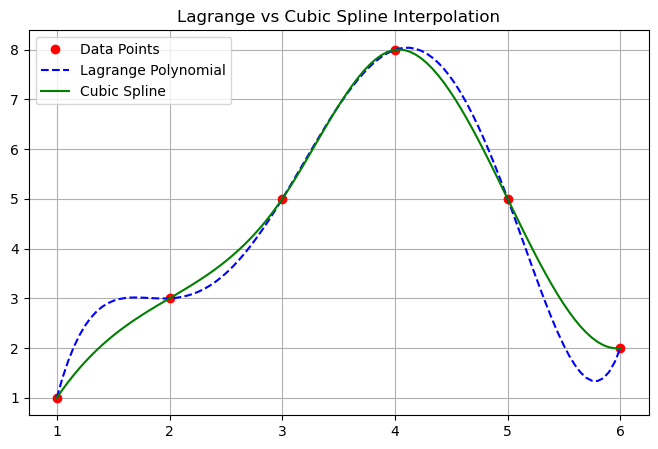

In [4]:
x_new = np.linspace(1, 6, 100)
plt.figure(figsize=(8, 5))
plt.plot(x_points, y_points, 'ro', label='Data Points')
plt.plot(x_new, poly_lagrange(x_new), 'b--', label='Lagrange Polynomial')
plt.plot(x_new, cs(x_new), 'g-', label='Cubic Spline')
plt.title('Lagrange vs Cubic Spline Interpolation')
plt.legend()
plt.grid()
plt.savefig('interpolation_plot.png')
plt.show()

<div dir=rtl>
<h2>
<font face="B Nazanin" color="#ffffff">
بخش 2: کار با فایل اکسل و رسم نمودار


In [5]:
print("\n--- بخش 2: فایل اکسل ---")
df = pd.read_excel('proj3.xlsx')
df


--- بخش 2: فایل اکسل ---


,Run time for different data size,Alg.1,Alg.2,Alg.3
0,100KB,50,200,100
1,200KB,55,220,200
2,300KB,60,240,300
3,400KB,65,260,400
4,500KB,70,280,500
5,600KB,75,300,600


In [6]:
def plot_charts(file_path):

    df = pd.read_excel(file_path)

    index_col = df.columns[0]
    df.set_index(index_col, inplace=True)

    # (Bar)
    df.plot(kind='bar', figsize=(10, 5))
    plt.title('Bar Chart of Execution Times')
    plt.ylabel('Time')
    plt.grid(axis='y')
    plt.savefig(f'bar_plot({file_path}).png')
    plt.show()

    # (Line)
    df.plot(kind='line', marker='o', figsize=(10, 5))
    plt.title('Line Chart of Execution Times')
    plt.ylabel('Time')
    plt.grid()
    plt.savefig(f'line_plot({file_path}).png')
    plt.show()

    # (Box)
    df.plot(kind='box', figsize=(10, 5))
    plt.title('Box Plot of Execution Times')
    plt.ylabel('Time')
    plt.grid(axis='y')
    plt.savefig(f'box_plot({file_path}).png')
    plt.show()

    return df

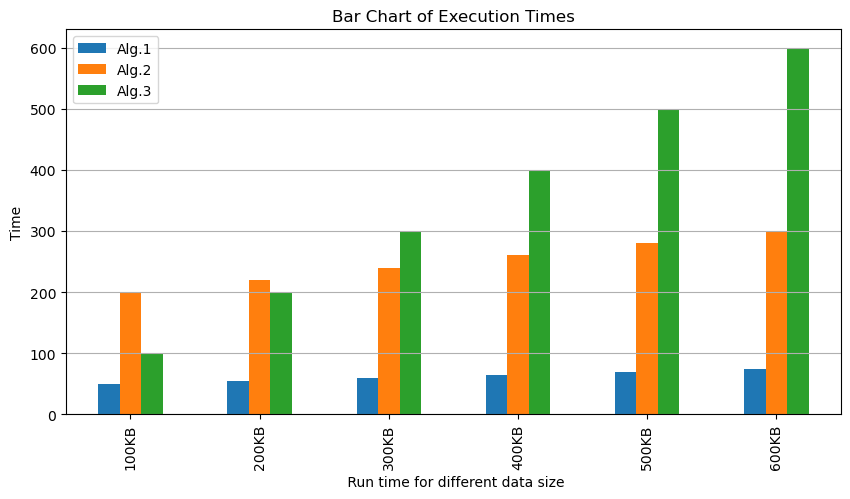

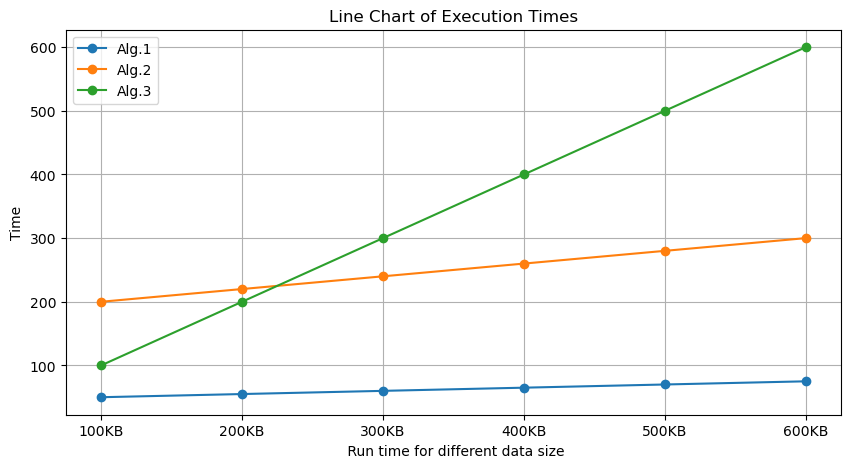

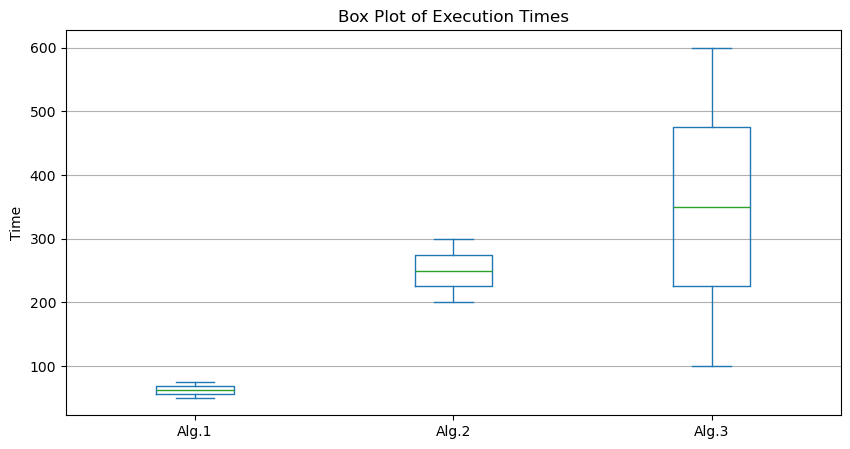

In [7]:
df_original = plot_charts('proj3.xlsx')

In [8]:
new_row = {df_original.index.name: '700KB', 'Alg.1': 80, 'Alg.2': 320, 'Alg.3': 700}
df.loc[len(df)] = new_row
df.to_excel('proj3_updated.xlsx', index=False)
df

,Run time for different data size,Alg.1,Alg.2,Alg.3
0,100KB,50,200,100
1,200KB,55,220,200
2,300KB,60,240,300
3,400KB,65,260,400
4,500KB,70,280,500
5,600KB,75,300,600
6,700KB,80,320,700


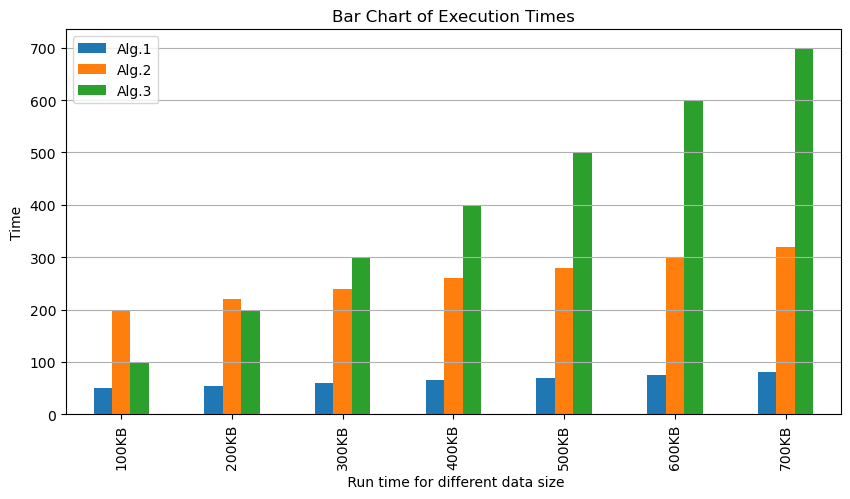

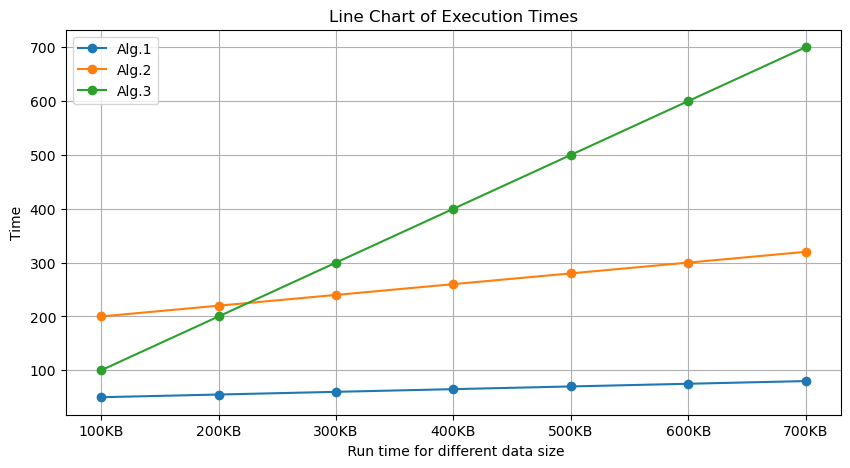

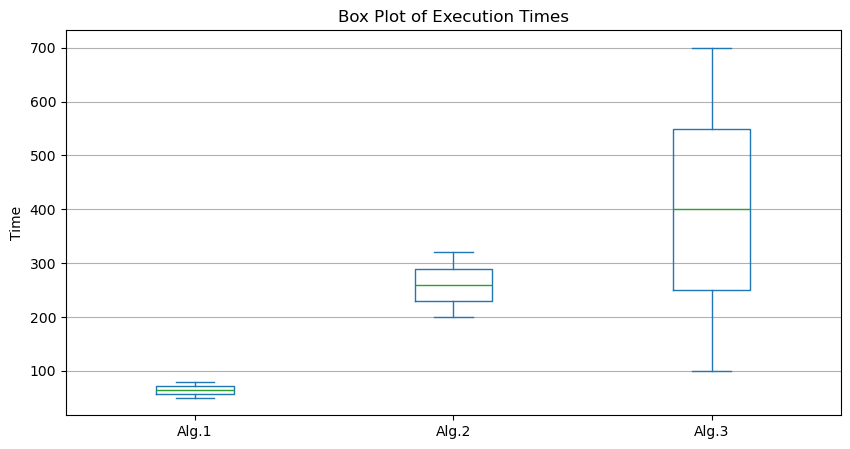

In [9]:
df_new = plot_charts('proj3_updated.xlsx')

In [10]:
mean_alg2 = df_original.iloc[0:6]['Alg.2'].mean()
print(f"میانگین زمان اجرای الگوریتم ۲ (برای داده‌های ۱۰۰ تا ۶۰۰) ")
print(f"Mean of Alg.2: {mean_alg2}")

میانگین زمان اجرای الگوریتم ۲ (برای داده‌های ۱۰۰ تا ۶۰۰) 
Mean of Alg.2: 250.0


<div dir=rtl>
<h2>
<font face="B Nazanin" color="#ffffff">
بخش 3: انتگرال‌گیری عددی


In [11]:
def f(x):
    return np.exp(x**2)

n_points = 1000
x_int = np.linspace(0, 1, n_points)
y_int = f(x_int)

integral_trap = trapezoid(y_int, x_int)
integral_simp = simpson(y_int, x=x_int)

In [12]:
integral_gauss, _ = fixed_quad(f, 0, 1, n=5)

print(f"مقدار انتگرال با روش ذوزنقه‌ای: {integral_trap:.8f}")
print(f"مقدار انتگرال با روش سیمپسون: {integral_simp:.8f}")
print(f"مقدار انتگرال با روش گوسی: {integral_gauss:.8f}")

مقدار انتگرال با روش ذوزنقه‌ای: 1.46265220
مقدار انتگرال با روش سیمپسون: 1.46265175
مقدار انتگرال با روش گوسی: 1.46265167
